# Energy Futures Inflation Measure Signal Strategies

This notebook will examine trading 5y5y forward inflation and Inflation Surprise Index using it as a signal. 

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
from   matplotlib.lines import Line2D
from   matplotlib.ticker import FuncFormatter


import statsmodels.api as sm
from   statsmodels.regression.rolling import RollingOLS

In [2]:
repo_path  = os.path.abspath(os.path.join(os.getcwd(), ".."))
data_path  = os.path.join(repo_path, "data")
latex_path = os.path.join(repo_path, "LaTex")

In [3]:
forward_path = os.path.join(data_path, "InflationForward.parquet")
df_forward   = (pd.read_parquet(
    path = forward_path, engine = "pyarrow").
    assign(group = "inf_forward").
    pivot(index = "date", columns = ["group", "country"], values = "value").
    apply(lambda x: np.log(x)).
    diff().
    shift().
    reset_index().
    melt(id_vars = [("date", "")]).
    rename(columns = {("date", ""): "date"}).
    dropna())

In [4]:
surprise_path = os.path.join(data_path, "InflationSurprise.parquet")
df_surprise   = (pd.read_parquet(
    path = surprise_path, engine = "pyarrow").
    assign(group = "inf_surp").
    pivot(index = "date", columns = ["group", "country"], values = "value").
    diff().
    shift().
    reset_index().
    melt(id_vars = [("date", "")]).
    rename(columns = {("date", ""): "date"}).
    dropna())

In [5]:
df_factors = pd.concat([df_forward, df_surprise])

In [6]:
fut_path = os.path.join(data_path, "FutPX.parquet")
df_rtn   = (pd.read_parquet(
    path = fut_path, engine = "pyarrow").
    pivot(index = "date", columns = "security", values = "PX_LAST").
    pct_change())

In [7]:
df_lagged = (df_rtn.apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = "date", var_name = "fut_ticker", value_name = "rtn").
    assign(target = "lagged"))

In [8]:
df_perf = (df_rtn.apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = "date", var_name = "fut_ticker", value_name = "rtn").
    assign(target = "perfect"))

In [9]:
df_longer_rtn = (df_rtn.reset_index().melt(
    id_vars = "date", var_name = "fut_ticker", value_name = "rtn").
    assign(target = "raw"))

In [10]:
df_fut_rtn = (pd.concat([
    df_lagged, df_perf, df_longer_rtn]).
    dropna())

# Background Research Fitting Returns

In [11]:
df_combined = (df_fut_rtn.merge(
    right = df_factors, how = "inner", on = ["date"]))

In [12]:
def _get_ols_params(df: pd.DataFrame) -> pd.DataFrame: 

    model = (sm.OLS(
        endog = df.rtn,
        exog  = sm.add_constant(df.value)).
        fit())
    
    df_param   = model.params.to_frame(name = "param_val").reset_index()
    df_pvalues = model.pvalues.to_frame(name = "pvalues").reset_index()
    df_tstats  = model.tvalues.to_frame(name = "tstat").reset_index()

    df_out = (df_param.merge(
        right = df_pvalues, how = "inner", on = ["index"]).
        merge(right = df_tstats, how = "inner", on = ["index"]))

    return df_out

df_params = (df_combined.assign(
    group_var = lambda x: x.fut_ticker + " " + x.target + " " + x.country + " " + x.group).
    groupby("group_var").
    apply(_get_ols_params))

Start by running a regression of the raw values (lagged) against the returns. In this case they values are differenced (and log applied to 5y5y forward). Since commodity returns are quite volatile, they need to be adjusted. In this case, a 10\% volatility target will suffice. Due to high intraday volatility swings two methods of volatility targeting will be used. The first is lagged, which is the true "real" returns of volatility targeting, regarding the fidelity of the backtest. Perfect volatility targeted is also implemented - although unachievable is also used. The futures data is daily and thus the lack of resolution within the data leads to a significant lag in volatility targeting.

In [13]:
renamer = {
    "inf_surp"   : "Inf Surp",
    "inf_forward": "5y5y"}

(df_params.reset_index().drop(
    columns = ["level_1"]).
    rename(columns = {"index": "param"}).
    melt(id_vars = ["group_var", "param"]).
    assign(
        str_split  = lambda x: x.group_var.str.split(" "),
        fut_ticker = lambda x: x.str_split.str[0],
        target     = lambda x: x.str_split.str[1],
        a          = lambda x: x.str_split.str[2] + " " + x.str_split.str[3].map(renamer)).
    rename(columns = {
        "a"         : "Factor",
        "variable"  : "",
        "target"    : "Vol. Target",
        "fut_ticker": "Future"}).
    replace({
        "const"    : r"$\alpha$",
        "value"    : r"$\beta$",
        "lagged"   : "Lagged",
        "perfect"  : "Perfect",
        "raw"      : "None",
        "tstat"    : r"$t$-stat",
        "pvalues"  : r"$p$-value",
        "param_val": "Param Val"}).
    pivot(index = ["Future", "Vol. Target", "param"], columns = ["", "Factor"], values = "value").
    apply(lambda x: np.round(x,3)))

Param Val                                  \
Factor                        UK 5y5y UK Inf Surp US 5y5y US Inf Surp   
Future Vol. Target param                                                
CL1    Lagged      $\alpha$     0.000       0.000   0.000       0.000   
                   $\beta$      0.009      -0.001   0.004      -0.002   
       None        $\alpha$     0.000       0.000   0.000       0.000   
                   $\beta$      0.040      -0.003   0.008      -0.009   
       Perfect     $\alpha$     0.000       0.000   0.000       0.000   
                   $\beta$      0.009      -0.001   0.004      -0.002   
CO1    Lagged      $\alpha$     0.000       0.000   0.000       0.000   
                   $\beta$      0.010      -0.002   0.007      -0.002   
       None        $\alpha$     0.000       0.000   0.000       0.000   
                   $\beta$      0.033      -0.005   0.016      -0.010   
       Perfect     $\alpha$     0.000       0.000   0.000       0.000   
                   $\beta$      0.010      -0.002   0.006      -0.002   
HO1    Lagged      $\alpha$     0.000       0.000   0.000       0.000   
                   $\beta$      0.012      -0.002   0.005      -0.002   
       None        $\alpha$     0.001       0.001   0.000       0.001   
                   $\beta$      0.042      -0.006   0.010      -0.012   
       Perfect     $\alpha$     0.000       0.000   0.000       0.000   
                   $\beta$      0.011      -0.002   0.005      -0.002   
NG1    Lagged      $\alpha$     0.000       0.000   0.000       0.000   
                   $\beta$     -0.007      -0.000   0.004      -0.002   
       None        $\alpha$     0.000       0.000   0.000       0.001   
                   $\beta$     -0.022      -0.005   0.011      -0.010   
       Perfect     $\alpha$    -0.000      -0.000  -0.000       0.000   
                   $\beta$      0.001      -0.000   0.002      -0.002   
QS1    Lagged      $\alpha$     0.000       0.000   0.000       0.000   
                   $\beta$      0.015      -0.002   0.007      -0.002   
       None        $\alpha$     0.000       0.000   0.000       0.000   
                   $\beta$      0.056      -0.006   0.011      -0.010   
       Perfect     $\alpha$     0.000       0.000   0.000       0.000   
                   $\beta$      0.014      -0.002   0.007      -0.002   
XB1    Lagged      $\alpha$     0.000       0.000   0.000       0.000   
                   $\beta$      0.005      -0.001   0.004      -0.001   
       None        $\alpha$     0.001       0.001   0.001       0.001   
                   $\beta$      0.022      -0.004   0.021      -0.003   
       Perfect     $\alpha$     0.000       0.000   0.000       0.000   
                   $\beta$      0.004      -0.001   0.004      -0.001   

                            $p$-value                                  \
Factor                        UK 5y5y UK Inf Surp US 5y5y US Inf Surp   
Future Vol. Target param                                                
CL1    Lagged      $\alpha$     0.713       0.400   0.870       0.259   
                   $\beta$      0.215       0.142   0.309       0.237   
       None        $\alpha$     0.419       0.223   0.535       0.142   
                   $\beta$      0.178       0.329   0.640       0.230   
       Perfect     $\alpha$     0.617       0.311   0.772       0.188   
                   $\beta$      0.214       0.128   0.347       0.217   
CO1    Lagged      $\alpha$     0.535       0.318   0.681       0.242   
                   $\beta$      0.160       0.058   0.100       0.269   
       None        $\alpha$     0.379       0.215   0.507       0.169   
                   $\beta$      0.195       0.091   0.260       0.140   
       Perfect     $\alpha$     0.402       0.216   0.532       0.154   
                   $\beta$      0.152       0.050   0.121       0.256   
HO1    Lagged      $\alpha$     0.173       0.107   0.305       0.043   
            

# Trading with Z-Scores

With the two signals 5y5y forward inflation and Inflation Surprise index (for UK and US respectively) calculate the 30 day exponentially weighted z-score, and then use that to trade the energy futures. For each group (factor and year) use a 10\% volatility target with signal returns. The volatility targeting is done perfectly and lagged to capture the intraday volatility effects of commodity futures. 

In [14]:
zscore_path = os.path.join(data_path, "ZScore.parquet")

In [15]:
def _lag_signal(df: pd.DataFrame) -> pd.DataFrame: 
    
    df_out = (df.sort_index().assign(
        lag_zscore = lambda x: x.value.shift()))

    return df_out

df_signal_rtn = (pd.read_parquet(
    path = zscore_path, engine = "pyarrow").
    set_index("date").
    assign(group_var = lambda x: x.security + " " + x.country + " " + x.group).
    groupby("group_var").
    apply(_lag_signal, include_groups = False).
    reset_index().
    assign(signal_rtn = lambda x: np.sign(x.lag_zscore) * x.fut_rtn))

In [16]:
df_combined = (df_signal_rtn.assign(
    tmp = lambda x: x.country + " " + x.group))

In [17]:
df_lagged = (df_combined.pivot(
    index = "date", columns = ["tmp", "security"], values = "signal_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = [("date", "")], value_name = "rtn").
    rename(columns = {("date", ""): "date"}).
    assign(target = "lagged"))

df_perf = (df_combined.pivot(
    index = "date", columns = ["tmp", "security"], values = "signal_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = [("date", "")], value_name = "rtn").
    rename(columns = {("date", ""): "date"}).
    assign(target = "perfect"))

In [18]:
df_plot = (pd.concat([
    df_lagged, df_perf]).
    drop(columns = ["security"]).
    dropna().
    groupby(["date", "tmp", "target"]).
    agg("mean").
    reset_index())

In [19]:
display(pd.concat([
    df_perf, df_lagged]).
    dropna().
    drop(columns = ["date"]).
    groupby(["tmp", "security", "target"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    assign(tmp = lambda x: x.tmp.str.replace("forward_inf", "5y5y").str.replace("surprise_inf", "Sur. Inf.")).
    rename(columns = {
        "tmp"   : "",
        "target": "Vol. Target"}).
    replace({
        "lagged" : "Lagged",
        "perfect": "Perfect"}).
    pivot(index = "security", columns = ["", "Vol. Target"], values = "rtn").
    apply(lambda x: np.round(x,3)))

UK 5y5y         UK Sur. Inf.         US 5y5y         US Sur. Inf.  \
Vol. Target  Lagged Perfect       Lagged Perfect  Lagged Perfect       Lagged   
security                                                                        
CL1           0.377   0.357        0.062   0.049   0.705   0.716       -0.466   
CO1           0.471   0.472        0.124   0.111   0.674   0.687       -0.430   
HO1           0.343   0.430       -0.127  -0.110   0.523   0.637       -0.407   
NG1           0.368   0.304       -0.220  -0.114   0.250   0.126        0.047   
QS1           0.438   0.518        0.047   0.020   0.761   0.878       -0.353   
XB1           0.203   0.271       -0.137  -0.192   0.456   0.554       -0.409   

                     
Vol. Target Perfect  
security             
CL1          -0.480  
CO1          -0.439  
HO1          -0.391  
NG1          -0.317  
QS1          -0.333  
XB1          -0.372

In [20]:
display(pd.concat([
    df_perf, df_lagged]).
    drop(columns = ["security", "date"]).
    dropna().
    groupby(["target", "tmp"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    assign(
        target = lambda x: x.target.str.capitalize(),
        tmp    = lambda x: x.tmp.str.replace("forward_inf", "5y5y").str.replace("surprise_inf", "Sur. Inf.")).
    rename(columns = {
        "tmp"   : "",
        "target": "Vol. Target"}).
    pivot(index = "Vol. Target", columns = "", values = "rtn").
    apply(lambda x: np.round(x,3)))

,UK 5y5y,UK Sur. Inf.,US 5y5y,US Sur. Inf.
Vol. Target,,,,
Lagged,0.331,-0.068,0.452,-0.241
Perfect,0.395,-0.032,0.605,-0.389


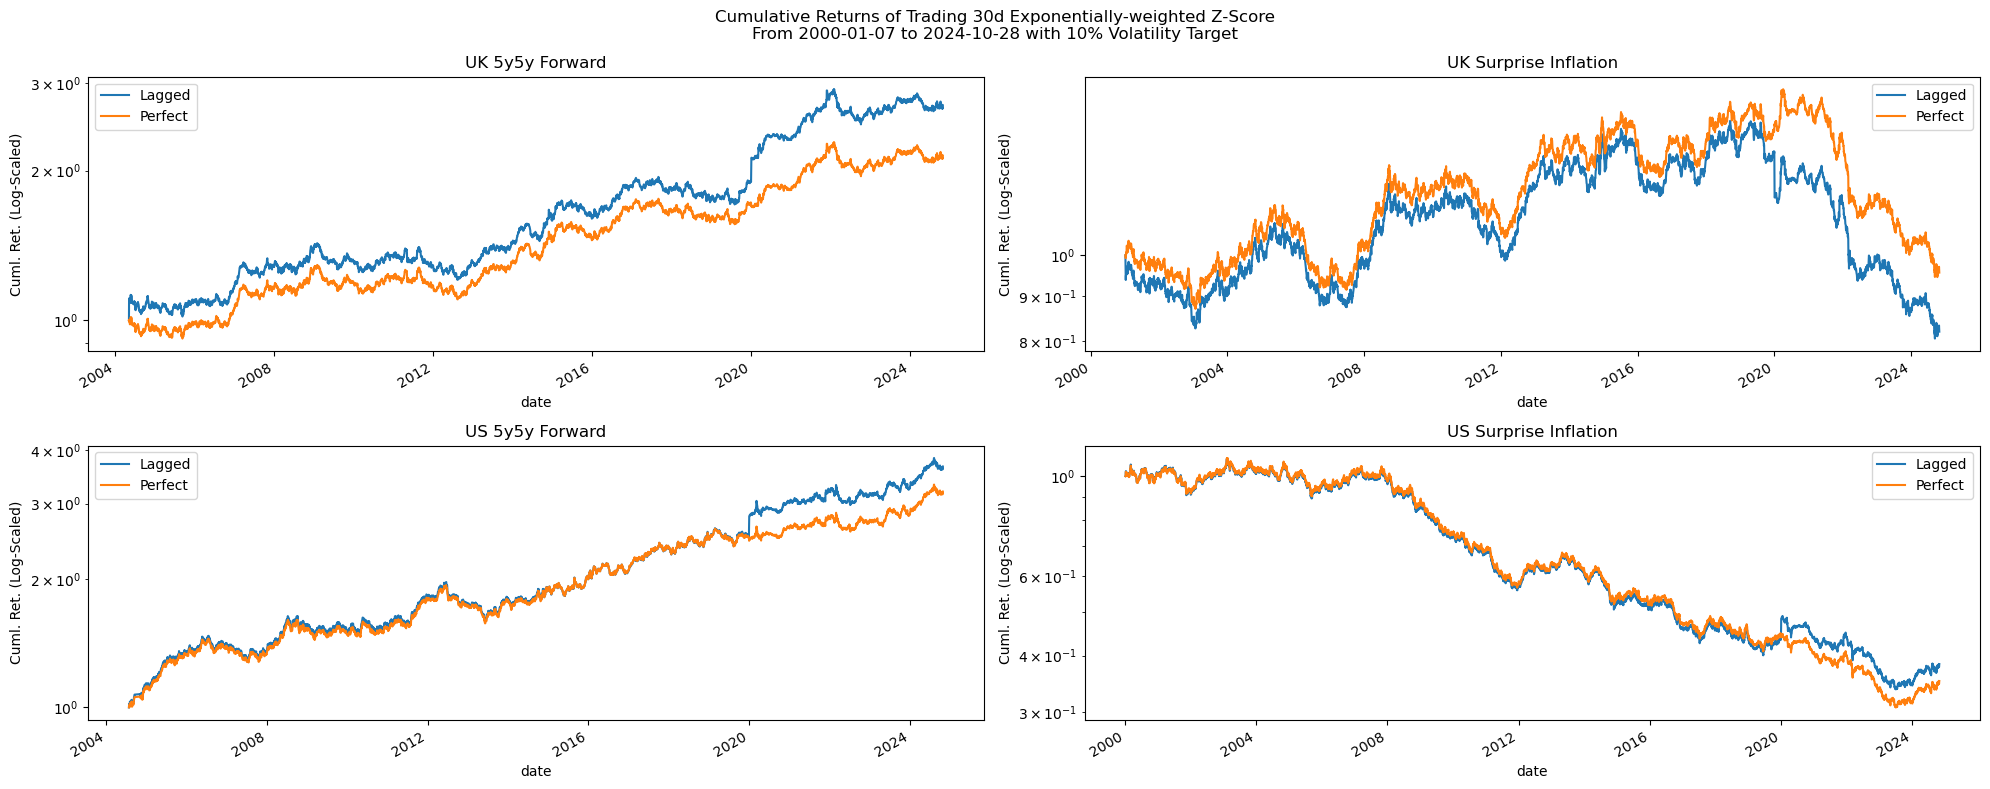

In [21]:
groups    = df_plot.tmp.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = 2, nrows = 2, figsize = (20,8)) 

for group, ax in zip(groups, axes.flatten()): 

    (df_plot.query(
        "tmp == @group").
        assign(
            target = lambda x: x.target.str.capitalize(),
            rtn    = lambda x: np.where(x.date == x.date.min(), 0, x.rtn)).
        rename(columns = {"target": ""}).
        pivot(index = "date", columns = "", values = "rtn").
        fillna(0).
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            ax     = ax,
            logy   = True,
            ylabel = "Cuml. Ret. (Log-Scaled)", 
            title  = group.replace("forward_inf", "5y5y Forward").replace("surprise_inf", "Surprise Inflation")))

fig.suptitle("Cumulative Returns of Trading 30d Exponentially-weighted Z-Score\nFrom {} to {} with 10% Volatility Target".format(
    df_plot.date.min().date(),
    df_plot.date.max().date()))
plt.tight_layout()

out_path = os.path.join(latex_path, "RawZScoreCumulativeReturns.png")
fig.savefig(out_path, dpi = 300)

# Trading Optimized Z-Scores

In [22]:
zscore_path = os.path.join(data_path, "OptimizedZScore.parquet")

In [23]:
df_opt_signal = (pd.read_parquet(
    path = zscore_path, engine = "pyarrow"))

In [24]:
df_lagged_port = (df_opt_signal.assign(
    name = lambda x: x.security + " " + x.country + " " + x.group + " " + x.sample_group).
    pivot(index = "date", columns = "name", values = "signal_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) > 0.3, np.nan, x)).
    reset_index().
    reset_index().
    melt(id_vars = "date").
    dropna().
    assign(
        str_split = lambda x: x.name.str.split(" "),
        port      = lambda x: x.str_split.str[1] + " " + x.str_split.str[2],
        group     = lambda x: x.str_split.str[-1])
    [["date", "port", "group", "value"]].
    groupby(["date", "port", "group"]).
    agg("mean").
    reset_index().
    assign(vol_target = "lagged"))

df_perf_port = (df_opt_signal.assign(
    name = lambda x: x.security + " " + x.country + " " + x.group + " " + x.sample_group).
    pivot(index = "date", columns = "name", values = "signal_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) > 0.3, np.nan, x)).
    reset_index().
    reset_index().
    melt(id_vars = "date").
    dropna().
    assign(
        str_split = lambda x: x.name.str.split(" "),
        port      = lambda x: x.str_split.str[1] + " " + x.str_split.str[2],
        group     = lambda x: x.str_split.str[-1])
    [["date", "port", "group", "value"]].
    groupby(["date", "port", "group"]).
    agg("mean").
    reset_index().
    assign(vol_target = "perfect"))

In [25]:
display(pd.concat([
    df_lagged_port, df_perf_port]).
    drop(columns = ["date"]).
    groupby(["port", "group", "vol_target"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    rename(columns = {"group": ""}).
    pivot(index = ["port", "vol_target"], columns = "", values = "value").
    assign(sharpe_spread = lambda x: x.out_sample - x.in_sample).
    reset_index().
    assign(vol_target = lambda x: x.vol_target.str.capitalize()).
    rename(columns = {
        "port"         : "Factor",
        "vol_target"   : "Vol. Target",
        "in_sample"    : "In-Sample",
        "out_sample"   : "Out-Sample",
        "sharpe_spread": "Sharpe Lost"}).
    melt(id_vars = ["Factor", "Vol. Target"]).
    assign(Factor = lambda x: (x.Factor.str.replace(
        "forward_inf", "5y5y").
        str.replace("surprise_inf", "Sur. Inf."))).
    pivot(index = "Factor", columns = ["", "Vol. Target"], values = "value").
    apply(lambda x: np.round(x,3)))

In-Sample         Out-Sample         Sharpe Lost        
Vol. Target     Lagged Perfect     Lagged Perfect      Lagged Perfect
Factor                                                               
UK 5y5y          0.410   0.441      0.577   0.536       0.167   0.095
UK Sur. Inf.     0.722   0.771     -0.040   0.009      -0.762  -0.762
US 5y5y          1.167   1.241      1.095   1.127      -0.072  -0.115
US Sur. Inf.     0.776   0.727      0.708   0.699      -0.068  -0.028

In [26]:
df_longer = (df_opt_signal[
    ["security", "group", "country", "signal_rtn", "sample_group"]].
    assign(raw_rtn = lambda x: x.signal_rtn.fillna(0)).
    rename(columns = {"signal_rtn": "adj_rtn"}).
    melt(id_vars = ["security", "group", "country", "sample_group"]).
    dropna())

In [27]:
df_lagged = (df_opt_signal.pivot(
    index = "date", columns = ["security", "group", "country", "sample_group"], values = "signal_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) == np.inf, np.nan, x)).
    reset_index().
    melt(id_vars = [("date", "", "", "")], value_name = "rtn").
    rename(columns = {("date", "", "", ""): "date"}).
    dropna().
    assign(vol_target = "lagged"))

In [28]:
df_perf = (df_opt_signal.pivot(
    index = "date", columns = ["security", "group", "country", "sample_group"], values = "signal_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) == np.inf, np.nan, x)).
    reset_index().
    melt(id_vars = [("date", "", "", "")], value_name = "rtn").
    rename(columns = {("date", "", "", ""): "date"}).
    dropna().
    assign(vol_target = "perf"))

In [29]:
df_sig_sharpe = (pd.concat([
    df_lagged, df_perf]).
    drop(columns = ["date"]).
    assign(adj_rtn = lambda x: np.where(x.rtn != 0, x.rtn, np.nan)).
    melt(id_vars = ["security", "group", "country", "sample_group", "vol_target"]).
    dropna().
    groupby(["security", "group", "country", "sample_group", "vol_target", "variable"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index())

In [30]:
display(df_sig_sharpe.
    replace({
        "forward_inf" : "5y5y",
        "surprise_inf": "Sur. Inf.",
        "lagged"      : "Lagged",
        "perf"        : "Perfect",
        "in_sample"   : "In-Sample",
        "out_sample"  : "Out-Sample",
        "adj_rtn"     : "Adjusted",
        "rtn"         : "Raw"}).
    rename(columns = {
        "sample_group": "",
        "vol_target"  : "Vol. Target",
        "variable"    : "Sharpe"}).
    pivot(
        index   = ["security", "group", "country"],
        columns = ["", "Vol. Target", "Sharpe"],
        values  = "value").
    apply(lambda x: np.round(x,3)))

In-Sample                        Out-Sample         \
Vol. Target                   Lagged         Perfect            Lagged          
Sharpe                      Adjusted    Raw Adjusted    Raw   Adjusted    Raw   
security group     country                                                      
CL1      5y5y      UK          0.310  0.309    0.249  0.249      0.185  0.137   
                   US          1.082  1.080    1.074  1.072      1.007  0.952   
         Sur. Inf. UK          0.350  0.349    0.407  0.406     -0.015 -0.011   
                   US          0.801  0.566    0.704  0.498      0.575  0.446   
CO1      5y5y      UK          0.512  0.363    0.489  0.347     -0.399 -0.303   
                   US          1.137  1.135    1.135  1.133      1.078  0.997   
         Sur. Inf. UK          0.247  0.174    0.320  0.226     -0.251 -0.181   
                   US          0.631  0.631    0.624  0.624      0.391  0.238   
HO1      5y5y      UK          0.578  0.410    0.906  0.642      0.523  0.353   
                   US          1.510  1.065    1.523  1.074      1.026  0.967   
         Sur. Inf. UK          1.116  0.791    1.085  0.770      0.616  0.422   
                   US          0.518  0.518    0.477  0.477      0.294  0.214   
NG1      5y5y      UK         -0.138 -0.138    0.269  0.268      0.394  0.383   
                   US         -0.048 -0.034    0.999  0.704      0.353  0.271   
         Sur. Inf. UK          0.398  0.397    0.463  0.462      0.097  0.090   
                   US            NaN    NaN      NaN    NaN     -0.144 -0.132   
QS1      5y5y      UK          0.411  0.289    0.638  0.449      0.762  0.584   
                   US          1.208  1.199    1.280  1.270      1.404  1.318   
         Sur. Inf. UK          0.806  0.566    0.825  0.579     -0.149 -0.132   
                   US          0.638  0.634    0.575  0.571      0.442  0.342   
XB1      5y5y      UK          0.446  0.446    0.519  0.519      0.271  0.256   
                   US          0.693  0.490    1.030  0.728      0.561  0.541   
         Sur. Inf. UK          1.300  0.918    1.357  0.958      0.074  0.054   
                   US          0.472  0.471    0.580  0.579      0.668  0.491   

                                            
Vol. Target                 Perfect         
Sharpe                     Adjusted    Raw  
security group     country                  
CL1      5y5y      UK         0.117  0.087  
                   US         0.998  0.943  
         Sur. Inf. UK         0.009  0.006  
                   US         0.641  0.497  
CO1      5y5y      UK        -0.075 -0.057  
                   US         1.073  0.993  
         Sur. Inf. UK        -0.223 -0.160  
                   US         0.645  0.393  
HO1      5y5y      UK         0.639  0.431  
                   US         1.014  0.956  
         Sur. Inf. UK         0.743  0.508  
                   US         0.705  0.514  
NG1      5y5y      UK         0.453  0.441  
                   US         0.389  0.299  
         Sur. Inf. UK         0.218  0.201  
                   US         0.641  0.584  
QS1      5y5y      UK         0.763  0.584  
                   US         1.455  1.365  
         Sur. Inf. UK        -0.213 -0.190  
                   US         0.346  0.267  
XB1      5y5y      UK         0.247  0.233  
                   US         0.611  0.589  
         Sur. Inf. UK         0.163  0.120  
                   US         0.667  0.491

In [31]:
df_plot = (pd.concat(
    [df_lagged_port, df_perf_port]).
    assign(
        group      = lambda x: np.where(x.group == "in_sample", "IS", "OOS"),
        vol_target = lambda x: np.where(x.vol_target == "lagged", "Lag", "Perf"),
        name       = lambda x: x.group + " " + x.vol_target,
        port       = lambda x: x.port.str.replace("forward_inf", "5y5y").str.replace("surprise_inf", "Surprise Inflation")))

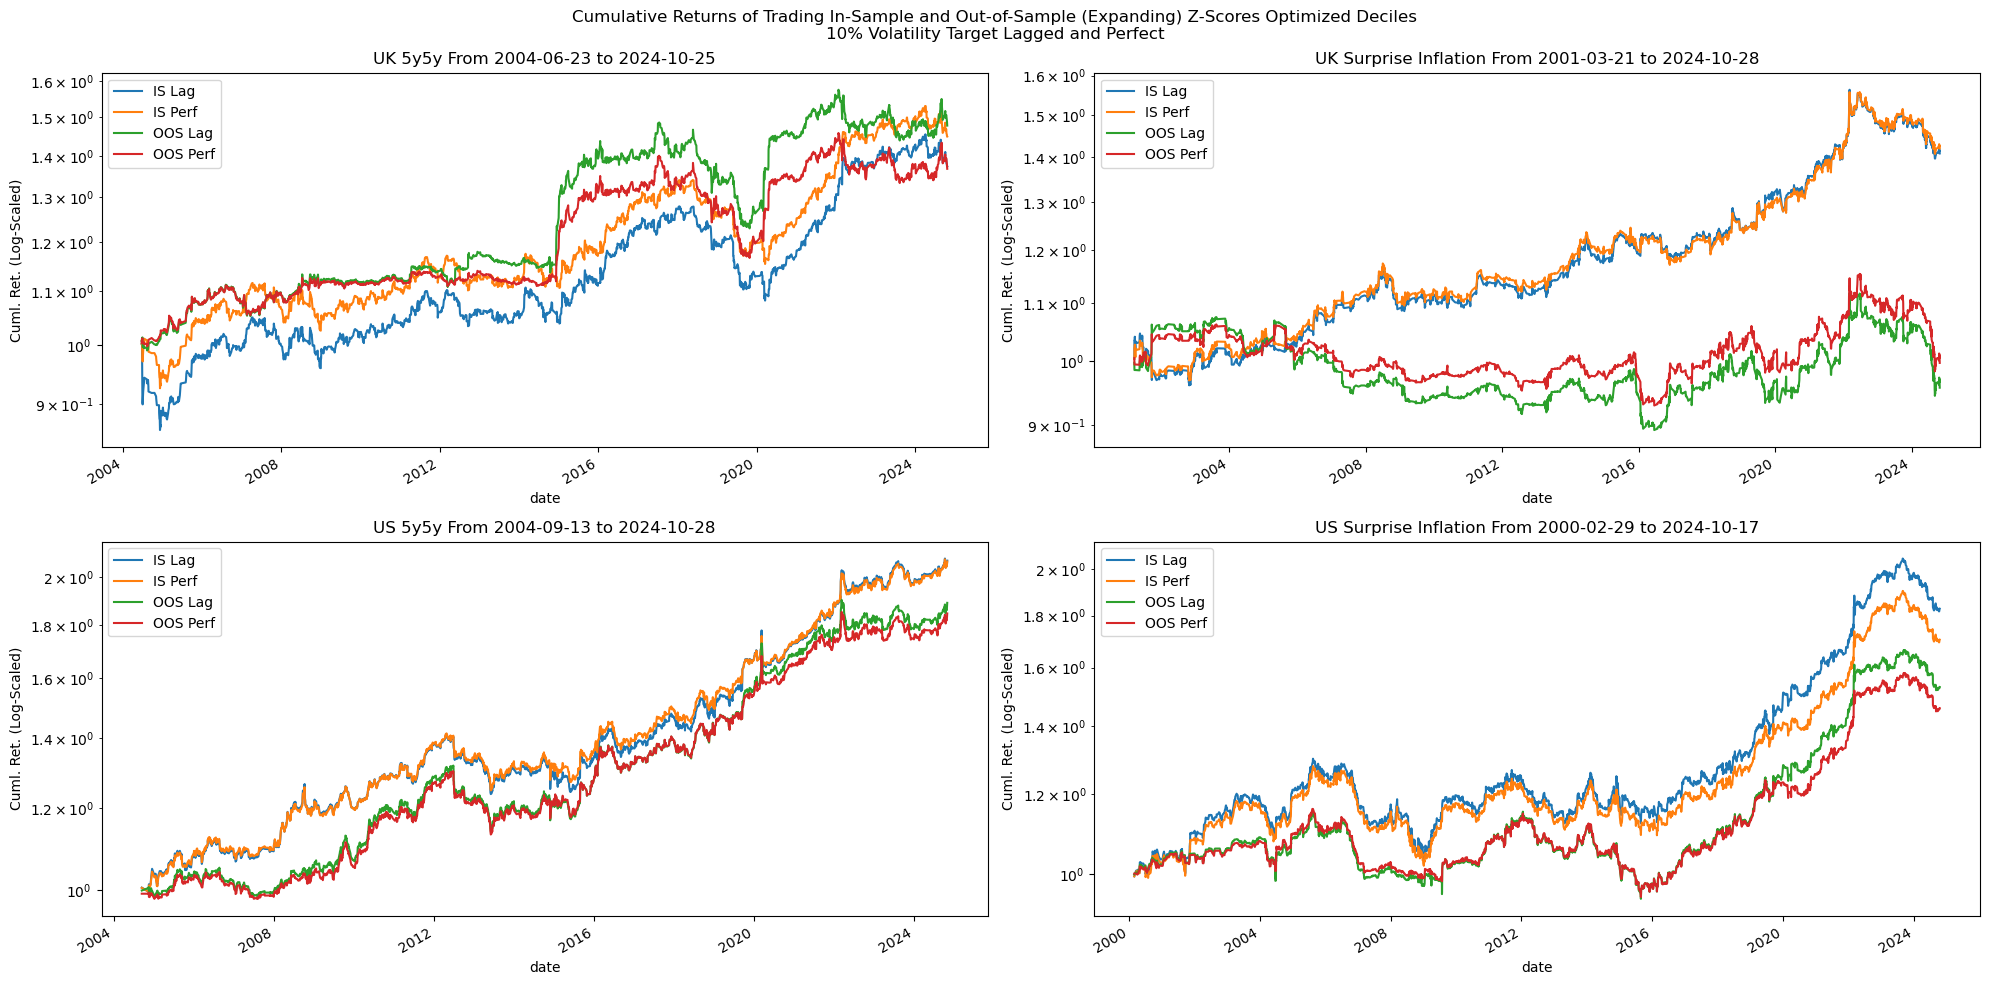

In [32]:
ports = df_plot.port.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = 2, nrows = 2, figsize = (20,10))

for port, ax in zip(ports, axes.flatten()): 

    df_plot_wider = (df_plot.query(
        "port == @port").
        rename(columns = {"name": ""}).
        pivot(index = "date", columns = "", values = "value").
        dropna())
        
    (df_plot_wider.
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            ax     = ax,
            logy   = True,
            ylabel = "Cuml. Ret. (Log-Scaled)",
            title  = "{} From {} to {}".format(
                port,
                df_plot_wider.index.min().date(),
                df_plot_wider.index.max().date())))

fig.suptitle("Cumulative Returns of Trading In-Sample and Out-of-Sample (Expanding) Z-Scores Optimized Deciles\n10% Volatility Target Lagged and Perfect")
plt.tight_layout()
out_path = os.path.join(latex_path, "OptZScoreCumulativeReturns.png")
fig.savefig(out_path)

# Trading OLS Regression

In [33]:
ols_path = os.path.join(data_path, "OLSResid.parquet")

In [34]:
df_resid = (pd.read_parquet(
    path = ols_path, engine = "pyarrow").
    assign(
        signal_rtn = lambda x: -np.sign(x.lag_resid) * x.fut_rtn,
        name       = lambda x: x.country + " " + x.group + " " + x.security + " " + x.sample_group))

In [35]:
df_resid_wider = df_resid.pivot(index = "date", columns = "name", values = "signal_rtn")

In [36]:
df_lagged = (df_resid_wider.apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    dropna().
    assign(target = "lagged"))

df_perf = (df_resid_wider.apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    dropna().
    assign(target = "perfect"))

In [37]:
df_port = (pd.concat([
    df_lagged, df_perf]).
    assign(
        str_split    = lambda x: x.name.str.split(" "),
        port         = lambda x: x.str_split.str[0] + " " + x.str_split.str[1],
        sample_group = lambda x: x.str_split.str[-1]))

In [38]:
df_port_rtn = (df_port.drop(
    columns = ["str_split", "name"]).
    groupby(["date", "target", "port", "sample_group"]).
    agg("mean").
    reset_index())

In [39]:
display(df_port_rtn.drop(
    columns = ["date"]).
    assign(port = lambda x: x.port.str.replace("forward_inf", "5y5y").str.replace("surprise_inf", "Sur. Inf.")).
    groupby(["target", "port", "sample_group"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    rename(columns = {
        "sample_group": "",
        "target"      : "Vol. Target"}).
    replace({
        "is"     : "In-Sample",
        "os"     : "Out-of-Sample",
        "lagged" : "Lagged",
        "perfect": "Perfect"}).
    pivot(index = "port", columns = ["Vol. Target", ""], values = "rtn").
    apply(lambda x: np.round(x,3)))

Vol. Target     Lagged                 Perfect              
             In-Sample Out-of-Sample In-Sample Out-of-Sample
port                                                        
UK 5y5y         -0.028        -0.031     0.133         0.143
UK Sur. Inf.    -0.043         0.006     0.148         0.264
US 5y5y         -0.112        -0.081     0.066         0.103
US Sur. Inf.    -0.071        -0.042     0.076         0.143

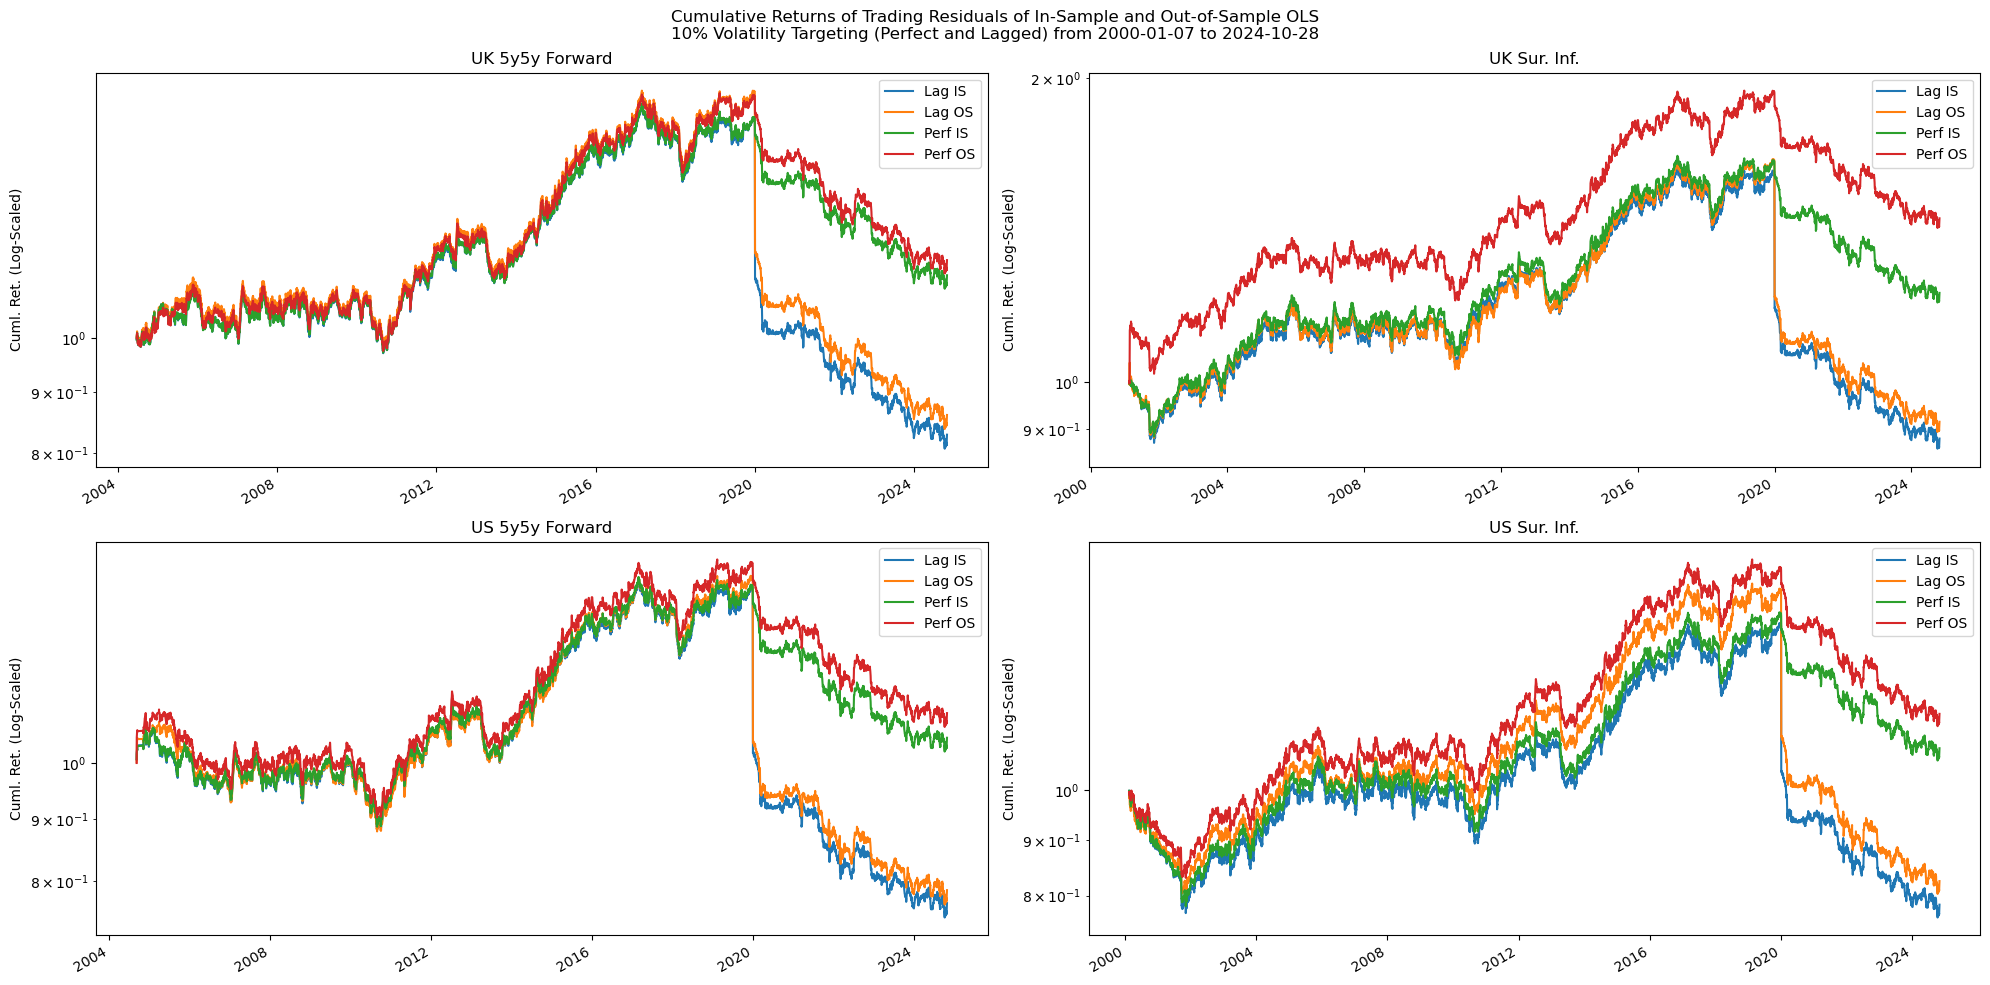

In [40]:
ports = df_port_rtn.port.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = 2, nrows = 2, figsize = (20,10))

for port, ax in zip(ports, axes.flatten()):

    (df_port_rtn.query(
        "port == @port").
        assign(
            target       = lambda x: np.where(x.target == "perfect", "Perf", "Lag"),
            sample_group = lambda x: x.sample_group.str.upper(),
            name         = lambda x: x.target + " " + x.sample_group).
        rename(columns = {"name": ""}).
        pivot(index = "date", columns = "", values = "rtn").
        dropna().
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            logy = True,
            ax   = ax,
            xlabel = "",
            ylabel = "Cuml. Ret. (Log-Scaled)",
            title  = port.replace("forward_inf", "5y5y Forward").replace("surprise_inf", "Sur. Inf.")))

fig.suptitle("Cumulative Returns of Trading Residuals of In-Sample and Out-of-Sample OLS\n10% Volatility Targeting (Perfect and Lagged) from {} to {}".format(
    df_port_rtn.date.min().date(),
    df_port_rtn.date.max().date()))
plt.tight_layout()

# OLS Deciled

In [41]:
def _get_decile(df: pd.DataFrame, q: int = 10) -> pd.DataFrame:

    df_decile = (df.assign(
        decile = lambda x: pd.qcut(x = x.resid, q = 10, labels = [i + 1 for i in range(10)]).shift()))

    df_decile_sharpe = (df_decile[
        ["decile", "fut_rtn"]].
        reset_index(drop = True).
        dropna().
        groupby("decile").
        agg(lambda x: x.mean() / x.std() * np.sqrt(252)))

    df_decile_tmp = (df_decile_sharpe.reset_index().query(
        "decile == [1,2,9,10]").
        assign(dec_group = lambda x: np.where(x.decile <= 2, "lgroup", "ugroup")))

    df_out = (df_decile_tmp.drop(
        columns = ["decile"]).
        groupby("dec_group").
        agg("prod").
        assign(signal_scaler = lambda x: np.where(x.fut_rtn > 0, 1, 0)).
        drop(columns = ["fut_rtn"]).
        merge(right = df_decile_tmp, how = "outer", on = ["dec_group"]).
        rename(columns = {"fut_rtn": "sharpe"}).
        merge(right = df_decile.reset_index(), how = "outer", on = ["decile"]).
        assign(signal_rtn = lambda x: np.sign(x.sharpe * x.signal_scaler) * x.fut_rtn))

    return df_out

df_opt_resid = (df_resid.query(
    "sample_group == 'is'").
    set_index("date").
    groupby("name").
    apply(_get_decile, include_groups = False).
    reset_index().
    drop(columns = ["level_1"]).
    assign(name = lambda x: x.group + " " + x.country + " " + x.security))

In [42]:
df_lagged = (df_opt_resid.pivot(
    index = "date", columns = "name", values = "signal_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) == np.inf, np.nan, x)).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    dropna().
    assign(target = "lagged"))

df_perfect = (df_opt_resid.pivot(
    index = "date", columns = "name", values = "signal_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) == np.inf, np.nan, x)).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    dropna().
    assign(target = "perfect"))

In [43]:
df_port = (pd.concat([
    df_lagged, df_perfect]).
    assign(
        str_split = lambda x: x.name.str.split(" "),
        factor    = lambda x: x.str_split.str[0],
        country   = lambda x: x.str_split.str[1],
        security  = lambda x: x.str_split.str[2],
        adj_rtn   = lambda x: np.where(x.rtn == 0, np.nan, x.rtn)).
    drop(columns = ["str_split", "name"]).
    melt(id_vars = ["date", "target", "factor", "country", "security"]).
    dropna())

In [44]:
(df_port.drop(
    columns = ["security"]).
    groupby(["date", "target", "factor", "country", "variable"]).
    agg("mean").
    reset_index().
    drop(columns = ["date"]).
    groupby(["target", "factor", "country", "variable"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    assign(
        factor = lambda x: np.where(x.factor == "forward_inf", "5y5y", "Sur. Inf.")).
    rename(columns = {
        "variable": "",
        "target"  : "Vol. Target"}).
    replace({
        "lagged" : "Lagged",
        "perfect": "Perfect",
        "adj_rtn": "Adj Sharpe",
        "rtn"    : "Raw Sharpe"}).
    pivot(index = ["factor", "country"], columns = ["Vol. Target", ""], values = "value").
    apply(lambda x: np.round(x,3)))

Vol. Target           Lagged               Perfect           
                  Adj Sharpe Raw Sharpe Adj Sharpe Raw Sharpe
factor    country                                            
5y5y      UK           0.391      0.244      0.539      0.373
          US           0.539      0.293      0.662      0.407
Sur. Inf. UK           0.477      0.326      0.596      0.433
          US           0.510      0.352      0.636      0.474

In [45]:
print(os.getcwd())

C:\Users\Diego\Documents\GitHub\CommodityForwardInflation\notebook
